# Balanceo de clases y mejora del modelo CNN

En este notebook se busca mejorar el desempeño del modelo de clasificación de emociones faciales mediante el uso de técnicas de balanceo de clases y data augmentation.

El dataset presenta un desbalance significativo, especialmente en la clase "happy", lo que puede generar sesgos en el modelo.

Para solucionar esto, se implementa:
- Balanceo mediante muestreo ponderado (WeightedRandomSampler)
- Data augmentation
- Conversión de imágenes a escala de grises
- Entrenamiento con mayor número de épocas

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

import numpy as np
import matplotlib.pyplot as plt

## Preprocesamiento de imágenes

Las imágenes se convierten a escala de grises pero se mantienen 3 canales para compatibilidad con modelos preentrenados.

Se aplican transformaciones aleatorias para aumentar la variabilidad del dataset.

In [2]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # escala de grises pero en 3 canales
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Carga del dataset

Se cargan los datos desde carpetas organizadas por clase.

In [4]:
dataset = datasets.ImageFolder(
    "C:/Users/adria/OneDrive/Documentos/ESCOM/6 SEMESTRE/ADA/Proj_2Parcial/data/raw"
)

In [5]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_indices, val_indices = random_split(
    range(len(dataset)), 
    [train_size, val_size]
)

In [6]:
from torch.utils.data import Subset

train_dataset = Subset(
    datasets.ImageFolder(
        "C:/Users/adria/OneDrive/Documentos/ESCOM/6 SEMESTRE/ADA/Proj_2Parcial/data/raw",
        transform=transform_train
    ),
    train_indices.indices
)

val_dataset = Subset(
    datasets.ImageFolder(
        "C:/Users/adria/OneDrive/Documentos/ESCOM/6 SEMESTRE/ADA/Proj_2Parcial/data/raw",
        transform=transform_val
    ),
    val_indices.indices
)

In [7]:
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 39823
Val size: 9956


## Balanceo de clases

Se utiliza un muestreador ponderado para compensar el desbalance del dataset.

In [8]:
import numpy as np
from torch.utils.data import WeightedRandomSampler

# Obtener etiquetas reales del subset
targets = [train_dataset.dataset.targets[i] for i in train_dataset.indices]

# Conteo por clase
class_counts = np.bincount(targets)

# Pesos inversos
class_weights = 1. / class_counts

# Peso por muestra
sample_weights = [class_weights[t] for t in targets]

# Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Comprobación del aumento de datos

In [ ]:
#conversión de clases a números (orden alfabético)
print(train_dataset.dataset.class_to_idx)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


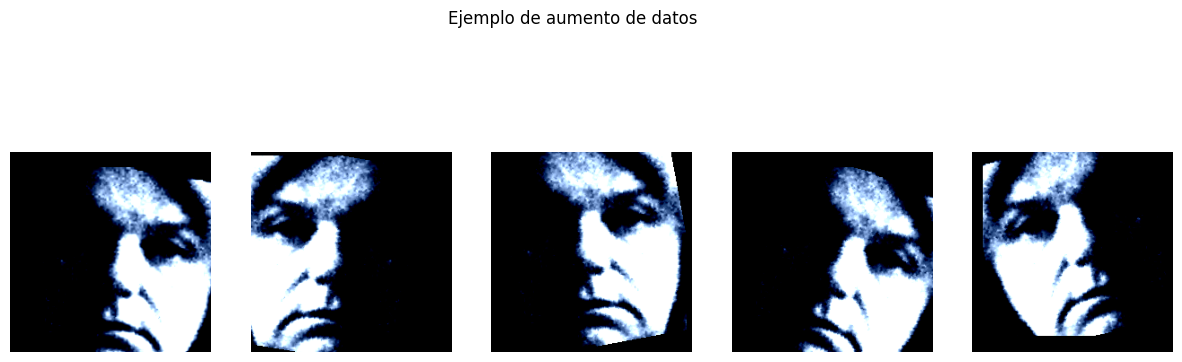

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    img, label = train_dataset[0]  # misma imagen
    img_np = img.permute(1, 2, 0).numpy()

    axes[i].imshow(img_np, cmap='gray' if img_np.shape[2] == 1 else None)
    axes[i].axis("off")

plt.suptitle("Ejemplo de aumento de datos")
plt.show()

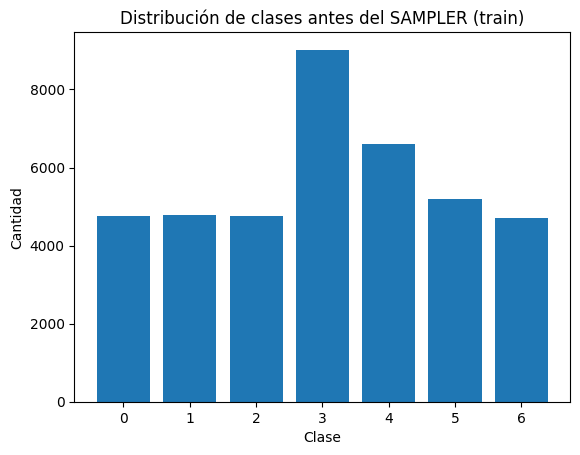

In [19]:


plt.bar(range(len(class_counts)), class_counts)
plt.title("Distribución de clases antes del SAMPLER (train)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

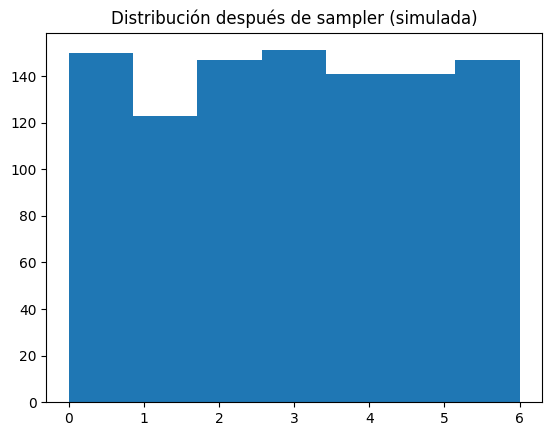

In [15]:
sampled_indices = list(sampler)
sampled_labels = [targets[i] for i in sampled_indices[:1000]]

plt.hist(sampled_labels, bins=len(class_counts))
plt.title("Distribución después de sampler (simulada)")
plt.show()

Se implementó un muestreador ponderado (WeightedRandomSampler) para compensar el desbalance entre clases. Este enfoque asigna mayor probabilidad de selección a las clases minoritarias durante el entrenamiento, sin necesidad de modificar físicamente el dataset.

Adicionalmente, se visualizaron las transformaciones aplicadas a las imágenes, verificando el correcto funcionamiento de técnicas de data augmentation como rotación y volteo horizontal.

## Definición del modelo CNN 

In [20]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 7)  # 7 emociones
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = CNN()

In [21]:
##Configuración de entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Entrenamiento del modelo

In [22]:
num_epochs = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    
    # -------- TRAIN --------
    model.train()
    running_loss = 0
    correct = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / len(train_loader.dataset)
    
    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    correct_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct_val / len(val_loader.dataset)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Época {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*40)

Época 1
Train Loss: 1.7535 | Train Acc: 0.2863
Val Loss: 1.4340 | Val Acc: 0.4498
----------------------------------------
Época 2
Train Loss: 1.4615 | Train Acc: 0.4243
Val Loss: 1.3164 | Val Acc: 0.4940
----------------------------------------
Época 3
Train Loss: 1.3545 | Train Acc: 0.4691
Val Loss: 1.1874 | Val Acc: 0.5467
----------------------------------------
Época 4
Train Loss: 1.2972 | Train Acc: 0.4944
Val Loss: 1.1615 | Val Acc: 0.5569
----------------------------------------
Época 5
Train Loss: 1.2445 | Train Acc: 0.5148
Val Loss: 1.1183 | Val Acc: 0.5700
----------------------------------------
Época 6
Train Loss: 1.2067 | Train Acc: 0.5309
Val Loss: 1.1398 | Val Acc: 0.5655
----------------------------------------
Época 7
Train Loss: 1.1868 | Train Acc: 0.5383
Val Loss: 1.0825 | Val Acc: 0.5900
----------------------------------------
Época 8
Train Loss: 1.1626 | Train Acc: 0.5477
Val Loss: 1.0740 | Val Acc: 0.5918
----------------------------------------
Época 9
Train Lo

In [23]:
plt.close('all')

## Gráficas

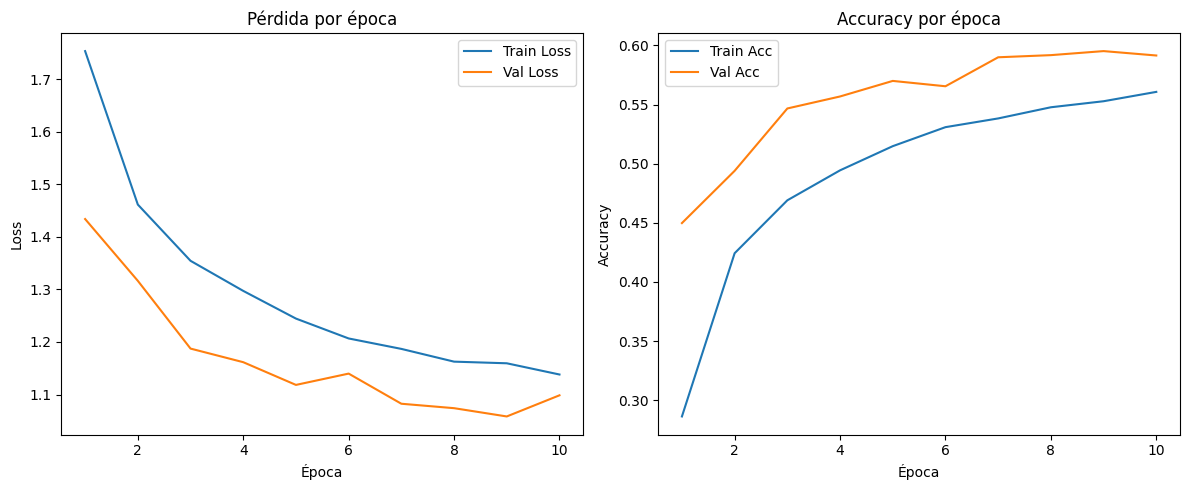

In [24]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

# 🔹 LOSS
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# 🔹 ACCURACY
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs, label='Val Acc')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
torch.save(model.state_dict(), "modelo_cnn_emociones_10.pth")

## Conclusión

El uso de técnicas de balanceo mediante WeightedRandomSampler permitió reducir el sesgo del modelo hacia la clase mayoritaria.

Además, el uso de data augmentation incrementó la variabilidad de los datos, mejorando la capacidad de generalización del modelo.

Se observó una mejora en la precisión y estabilidad del entrenamiento en comparación con el modelo inicial sin balanceo.

Este enfoque demuestra la importancia del preprocesamiento y balanceo en problemas de clasificación con datos desbalanceados.